In [1]:
###############################################################################
# WaterTAP Copyright (c) 2020-2026, The Regents of the University of California,
# through Lawrence Berkeley National Laboratory, Oak Ridge National Laboratory,
# National Laboratory of the Rockies, and National Energy Technology
# Laboratory (subject to receipt of any required approvals from the U.S. Dept.
# of Energy). All rights reserved.
#
# Please see the files COPYRIGHT.md and LICENSE.md for full copyright and license
# information, respectively. These files are also available online at the URL
# "https://github.com/watertap-org/watertap/"
###############################################################################

# Pricetaker for Flexible RO- Detailed Example
This tutorial expands on the functionalities in the [Flex Recovery Tutorial](../flex_recovery/flex_recovery.ipynb) by providing a more complex example.
The additional complexities arise from:
* RO energy intensity is a function of both recovery and flowrate
* Pretreatment (UltraFiltration) has an energy use function
* Adding costs for brine, feed, and chemicals
* Estimating equipment replacement costs based on number of shutdowns and startups 
* Calculation of flexibility metrics
* Onsite energy generation from a Photovoltaix (PV) system
* Demand Response Events in the electricity price signals

The workflow is similar to the [Flex Recovery Tutorial](../flex_recovery/flex_recovery.ipynb)- however, there are some significant differences in the underlying unit models, which will be noted throughout. The most important differences are the new unit models for UF and RO in the [Unit Model](../../../watertap/flowsheets/flex_desal/flex_recovery_and_flow_unit_models.py) definition and the additional functions located in the [flowsheet](../../../watertap/flowsheets/flex_desal/flex_recovery_and_flow_flowsheet.py). An implication of these changes is that the problem is more non-linear and has longer solve times.

In this tutorial, we will first create functions for each step to create the multiperiod pricetaker model, then compare the results for flexible operations under three different electricity rate structures.


## Facility Description
This example was developed using operational data from the Water Replenishment District (WRD) ARC facility in Pico Rivera, CA.

The plant is modeled by 4 RO trains, 3 UF pumps and 1 UV unit. The energy intensity of the UF pumps is represented as a quadratic function of flowrate while the energy intensity of each RO train is a function of flowrate and recovery. The UV (post-treatment) is modeled by a constant specific energy. 

The facility pays for both feed water and brine discharge. Pre and post treatment processes include chemical addition

#### Simplified Schamatic of WRD Facility as Implemented for Pricetaker Example
<img src="WRD_schematic.png" width="1200" height="400">


#### Note on Model Development
A flowsheet was developed using WaterTAP units models (pumps, RO, UV, etc.) and validated against facility data. Then energy surrogate functions were created using [Parameter Sweep](../../parameter_sweep_demo.ipynb). The resulting quadratic fit (for UF) and 2D surrogate (for RO) were integrated into the energy intensity equations in the Pricetaker formulation. 

The physical constraints of the system (recovery, flow, # of trains in operation, start-up times, etc.) are defined in the params of each subsystem.

## Step 1: Import libraries and load price signals and PV power data

In [2]:
import pyomo.environ as pyo
import pandas as pd

from idaes.apps.grid_integration import PriceTakerModel

from watertap.flowsheets.flex_desal import flex_recovery_and_flow_flowsheet as fs
from watertap.flowsheets.flex_desal import flex_recovery_and_flow_utils as utils
from watertap.flowsheets.flex_desal.flex_recovery_and_flow_params import FlexDesalParams
from watertap.core.solvers import get_solver
solver = get_solver()


def load_price_data(csv_path):
    df = pd.read_csv(csv_path)
    df["Energy Rate"] = (
        df["electric_energy_on_peak"]
        + df["electric_energy_mid_peak"]
        + df["electric_energy_off_peak"]
        + df["electric_energy_super_off_peak"]
    )
    df["Fixed Demand Rate"] = df["electric_demand_fixed"]
    df["Var Demand Rate"] = df["electric_demand_peak"]
    df["Customer Cost"] = df["electric_customer_fixed_charge"]
    df["Demand_Response_Price"] = df["electric_demand_response_price"]
    df["Emissions Intensity"] = 0 # Must be included, even if not tracked

    peak_hours = df["Var Demand Rate"].to_numpy() != 0
    pv_kw = df["solar_output_kW"]
    pv_cap = max(pv_kw)
    pv_cf = pv_kw / pv_cap
    return df, peak_hours, pv_cap, pv_cf


def set_price_data(csv_path):
    # Load pricing and PV data from CSV and update globals used by model-building steps.
    global price_data, peak_hours, pv_capacity, pv_capacity_factors
    (
        price_data,
        peak_hours,
        pv_capacity,
        pv_capacity_factors,
    ) = load_price_data(csv_path)


## Step 2: Build Model 
Create an instance of the PriceTakerModel, set parameters for each subsystem, and build the multiperiod model

In [3]:
def build_model():
    # Find start and end datetimes and time step  from the price data
    price_datetimes = pd.to_datetime(price_data["DateTime"])
    data_start = price_datetimes.iloc[0]
    data_next_time = price_datetimes.iloc[1]
    timestep_hours = (data_next_time - data_start).total_seconds() / 3600
    start_date = data_start.strftime("%Y-%m-%d %H:%M:%S")
    end_date = price_datetimes.iloc[-1].strftime("%Y-%m-%d %H:%M:%S")


    m = PriceTakerModel()
    m.params = FlexDesalParams(
        start_date=start_date,
        end_date=end_date,
        annual_production_AF=14000,
        timestep_hours=timestep_hours,
        include_onsite_solar=True,
        onsite_capacity=pv_capacity,
        CAPEX_yr=6498300,  # For WRD, this assumes a 30 yr lifetime
        include_demand_response=True, # For now, this value is 0
    )

    m.params.intake.update(
                {
                    "energy_intensity": 0,
                    "nominal_flowrate": 2500, # m3/hr # Note this is treated as an upper bound! (Should it be renamed??)
                    "feed_cost": 0.16, # $/m3
                }
            )  

    m.params.uf.update(
        {
            "minimum_downtime": 2, # hours
            "startup_delay": 2,
            "minimum_flowrate": 344,  # m3/hr
            "nominal_flowrate": 900,
            "maximum_flowrate": 989,
            "surrogate_type": "quadratic_energy_intensity", # kWh/m3 = a + b*flowrate + c*flowrate^2
            "surrogate_a": 2.71e-1,
            "surrogate_b": -3.32e-4,
            "surrogate_c": 2.39e-7,
            "nominal_recovery": 0.96, # fixed UF recovery
            "num_uf_pumps": 3, # plant has 4 pumps, but only a maximum of 3 on at one time
            "chemical_cost": 0.0332, # $/m3 # pretreatment chemical costs
        }
    )

    m.params.ro.update(
        {
            "startup_delay": 2,  # hours
            "minimum_downtime": 2,  
            "num_ro_skids": 4,
            "max_num_skids_shutdown_per_timestep": 2,
            "minimum_flowrate": 520,  # m3/hr
            "nominal_flowrate": 602,
            "maximum_flowrate": 635,
            "allow_variable_recovery": True,
            "surrogate_type": "PySMO_polyfit", # Key difference is that the surrogate is PySMO. Any PySMO surrogate should work
            "surrogate_file": "assets/ro_SEC_poly_fit_order_2.json", # order_1 can also be used and should improve the solve time
            "minimum_recovery": 0.88,
            "nominal_recovery": 0.925,
            "maximum_recovery": 0.925,

            "replacement_types": ["membranes", "motors"], # TODO [Insert link] for documentation on replacement cost calculation 
            "replacement_costs": [500 * 4 * (72 + 30 + 15), 125000],  # $ per replacement
            "replacement_lifetimes": [5, 20],  # years
            "replacement_max_flex_penalty": [0.1, 0.1],  # Reduction in lifetime if shutdowns occurs every day
        }
    )

    # Postreatment is a UV system
    m.params.posttreatment.update(
        {
            "energy_intensity": 0.101, # kWh/m3
            "chemical_cost": 0.0310, # $/m3
        }
    ) 

    m.params.brinedischarge.update({"brine_cost": 0.43, "energy_intensity": 0})

    m.append_lmp_data(lmp_data=price_data["Energy Rate"])

    # The flex_recovery_and_flow_flowsheet in watertap.flowsheets.flex_desal calls the WRD specific unit models
    # Corresponding changes had to be made to watertap.flowsheets.params 
    m.build_multiperiod_model(
        flowsheet_func=fs.build_desal_flowsheet,
        flowsheet_options={"params": m.params},
    )

    return m

## Step 3: Add constraints and fix operation variables
Many of the constraints specific to this implementation of Pricetaker are included in the [flowsheet](../../../watertap/flowsheets/flex_desal/flex_recovery_and_flow_flowsheet.py)

In [4]:
def add_constraints(m):
    # Setting values for the electricity costs
    m.update_operation_params(
        {
            "fixed_demand_rate": price_data["Fixed Demand Rate"],
            "variable_demand_rate": price_data["Var Demand Rate"],
            "emissions_intensity": price_data["Emissions Intensity"],
            "customer_cost": price_data["Customer Cost"],
            "demand_response_price": price_data["Demand_Response_Price"],
        }
    )

    # Setting energy generated by PV 
    m.update_operation_params(
        {"power_generation.capacity_factor": pv_capacity_factors}
    )

    # Add demand cost and fixed cost calculation constraints
    fs.add_demand_and_fixed_costs(m)

    # Add the startup delay constraints
    fs.add_delayed_startup_constraints(m)

    # Add a limit to the shutdown rate
    fs.add_num_skids_shutdown_constraints(m)

    # Ensure consistent ending and starting states of the plant
    # This may not be needed depending on use case
    fs.begin_and_end_constraint(m)


## Step 4: Construct useful expressions and model-level constraints

In [5]:
def add_expressions(m):    
    # Add the demand response revenue calculations
    fs.add_useful_expressions(m) # This is kind of a vague function name...

    # Add costs for brine, feed, and chemical flows
    fs.add_flow_costs(m)

    # These could all be combined into the "add_useful_expressions" function
    m.total_water_production = pyo.Expression(
        expr=m.params.timestep_hours
        * sum(m.period[:, :].posttreatment.product_flowrate)
        )

    m.total_energy_cost = pyo.Expression(expr=sum(m.period[:, :].energy_cost))

    # Demand costs are automatically normalized by number of months
    # If time horizon is a week, the cost is multiplied by 7 / 31
    m.total_demand_cost = pyo.Expression(expr=m.fixed_demand_cost + m.variable_demand_cost)

    m.total_customer_cost = pyo.Expression(expr=sum(m.period[:, :].customer_cost)*m.params.num_months)

    m.total_op_cost = pyo.Expression(
        expr=m.total_energy_cost
        + m.total_demand_cost
        + m.total_customer_cost
        - m.total_demand_response_revenue
        + m.total_feed_cost
        + m.total_brine_cost
        + m.total_chemical_cost
        )

    # add CAPEX as a fixed cost to calculate LCOW
    m.fixed_cost = pyo.Expression(expr=m.params.CAPEX_yr * m.params.num_months / 12)
    m.total_cost = pyo.Expression(expr=m.total_op_cost + m.fixed_cost)

    m.LCOW = pyo.Expression(expr=m.total_cost / m.total_water_production)  # $/m3

    # fix the UF recovery
    utils.fix_uf_recovery(m, uf_recovery=m.params.uf.nominal_recovery)

    fs.constrain_water_production(m)


## Step 5: Define a penalty term for changing the flowrate between hours

#### Note: The penalty term allows the solver to consider two important factors:
1) makes a distinction between patterns. For example, on-on-off-off should be preferred to an on-off-on-off pattern

2) the optimal solution will have steady flowrates, instead of +/- 5% flowrate fluctuations between hours which can appear due to similar energy intensities between those flowrates

In [6]:
def add_flow_changes_penalty(m):
    # Adds m.flow_changes_penalty, which is proportional to the number of times an RO train or UF pump changes flowrate between hours 
    # Applied to both the RO and UF systems
    fs.add_flow_changes_penalty(m)

    # TODO: Include documetation on how this penalty term is calculated

## Step 6: Add objective function to minimize operating costs

In [7]:
def add_objective(m):
    m.obj = pyo.Objective(
                expr=1e-4
                * (
                    m.total_energy_cost
                    + m.total_demand_cost
                    + m.total_customer_cost
                    - m.total_demand_response_revenue
                    + m.total_feed_cost
                    + m.total_brine_cost
                    + m.total_chemical_cost
                    + m.flow_changes_penalty
                ),
                sense=pyo.minimize,
            )

## Step 7: Call the solver

Pricetaker formulation uses binary variables and therefore cannot be solved using the normal watertap solver (ipopt). The solver options given below should be appropriate, though only Gurobi has been explicitly tested

In [8]:
def solve_PT_model(m):
    # These could also be inputs to the function instead
    solver_name = "gurobi"
    # solver_name = "baron"
    # solver_name = "scip"
    # solver_name = "cplex"
    mip_gap = 0.03 # 3% MIP gap. This value can be reduced, but may significantly increase solve time without improving the solution.

    if solver_name == "gurobi":
        solver = pyo.SolverFactory("gurobi_direct_minlp")
        solver.options["MIPGap"] = mip_gap
        results = solver.solve(m, tee=True)
        
    # HAVEN"T TESTED WITH THESE SOLVERS YET
    # elif solver_name == "scip":
    #     solver = pyo.SolverFactory("scip", validate=False)
    #     results = solver.solve(m, tee=True)

    # elif solver_name in ["baron", "cplex"]:
    #     solver = pyo.SolverFactory("gams")
    #     results = solver.solve(
    #         m, tee=True, solver=solver_name, add_options=[f"options optcr={mip_gap};"]
    #     )

    pyo.assert_optimal_termination(results)

## Step 8: Perform the post solve calculations

Replacement costs are calculated as a function of the number of start-up and shutdowns. The parameters used in the flex_desal params based on the [Chino Desalter Authority II facility](https://www.sciencedirect.com/science/article/pii/S0011916426002535?via%3Dihub)

TODO: Add documentation on for this equation!

Note- The replacement costs could be added to the operational costs (and the objective function). However, the formulation of the cost equation increases the non-lineararity and computational difficulty of the problem, for a component of << 1% of the total costs. To avoid this, the cost is calculated after the solve. 


The flexibility metrics implemented here are defined in [valuing energy flexibility from water systems](https://doi.org/10.1038/s44221-024-00316-4). The baseline is a steady state level of water production that achieves the weekly water target. 

In [9]:
def post_solve_calculations(m):
    # Calculate the replacement costs
    fs.calculate_replacement_costs(m)

    # Calculate the flexibility metrics
    # TODO: Double check these baseline numbers
    fs.calculate_flexibility_metrics(
            m,
            baseline_power=1080,
            baseline_electricity_cost=50843,  # $
            baseline_replacement_cost=992,
        ),
    
    design_var_values = m.get_design_var_values()
    # The flowrate change penalty variables are added to m, but are not design variables!
    filtered_design_var_values = {
        k: v
        for k, v in design_var_values.items()
        if "flow_change" not in k and "flow_changed" not in k and "reduction" not in k
    }

## Step 9: Save outputs and plot operations

In [10]:
def outputs(m, output_name):    
    m.get_operation_var_values().to_csv(f"assets/results/{output_name}.csv")
    print(f"Saved operation variable results to: assets/results/{output_name}.csv")

    utils.flex_recovery_and_flow_plot_function(
        m,
        n_time_points=len(price_data),
        peak_hours=peak_hours,
    )

## Step 10: Run the model

In [11]:
def run_model(result_name="result"):
    m = build_model()
    add_constraints(m)
    add_expressions(m)
    add_flow_changes_penalty(m)
    add_objective(m)
    # TODO: Address how we want to handle testing the notebook without an appropriate solver.
    try:
        solve_PT_model(m)
    except Exception as e:
        error_message = str(e)
        if "gurobi_direct_minlp" in error_message and "not available" in error_message:
            print("\nDetected unavailable solver: gurobi_direct_minlp\n")
            # Run specific fallback code only for this solver-not-found error.
            # Replace the line below with your custom fallback logic.
            print("Solving with ipopt instead for testing purposes, but the solution will not satisfy the binary variables.")
            solver = get_solver()
            results = solver.solve(m, tee=True)
            pyo.assert_optimal_termination(results)
        else:
            raise

    post_solve_calculations(m)
    outputs(m, result_name) # This doesn't output the plot to the notebook, but saves it as a file instead. Maybe that's fine?

## Example Analysis: Comparison of different rate structures

This tool can be used to evaluate how different rate structures impact optimal operations and energy use. The example below shows how the best rate structure for the facility depends flexible operations.

NOTE: THE RESULTS IN THE FOLLOWING SECTION WHERE OBTAINED USING GUROBI. RUNNING THIS NOTEBOOK WITH AN INAPPROPRIATE SOLVER (LIKE IPOPT) WILL RESULT IN DIFFERENT AND INVALID RESULTS.

### Existing Rate Structure

2026-09-29 18:42:18 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 

2026-09-29 18:42:18 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 

2026-09-29 18:42:18 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 

2026-09-29 18:42:18 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 



...


Explored 11151 nodes (12322095 simplex iterations) in 649.51 seconds (1168.50 work units)
Thread count was 32 (of 104 available processors)

Solution count 10: 14.1217 14.1555 14.2137 ... 15.0199

Optimal solution found (tolerance 3.00e-02)


Best objective 1.412165251419e+01, best bound 1.375030653905e+01, gap 2.6296%


Maximum power (kW): 1346.80
Discharge energy capacity (kWh): 9869.49
Charge energy capacity (kWh): 34781.58


Levelized Cost of Flexibility ($/kWh): 1.67


Saved operation variable results to: assets/results/summer_week_result.csv


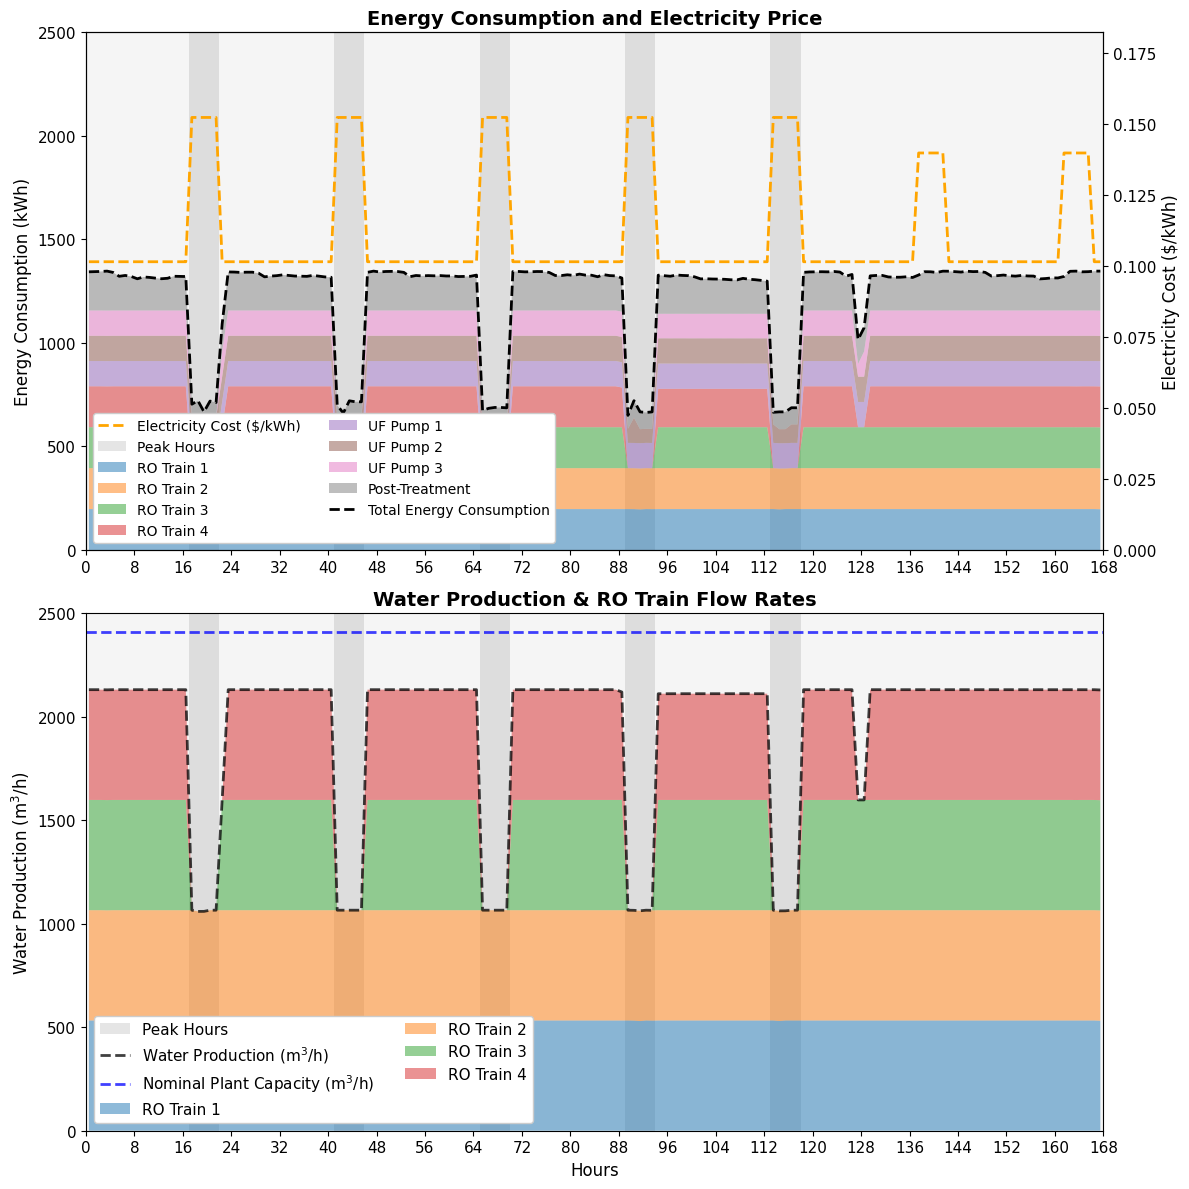

In [12]:
# Run the model with the existing rate structure
set_price_data("assets/pricesignal_flex_recovery_and_flow_summer.csv")
run_model(result_name="summer_week_result")

### Demand Response Event

2026-09-29 18:53:12 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 

2026-09-29 18:53:12 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 

2026-09-29 18:53:12 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 

2026-09-29 18:53:12 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 



...


Cutting planes:
  Learned: 164
  Gomory: 16
  Cover: 60
  Implied bound: 371
  Projected implied bound: 69
  Clique: 1
  MIR: 758
  StrongCG: 2
  Flow cover: 636
  GUB cover: 45
  Network: 4
  RLT: 1578
  Relax-and-lift: 179
  BQP: 31
  PSD: 10



Explored 7937 nodes (13079431 simplex iterations) in 506.79 seconds (878.06 work units)
Thread count was 32 (of 104 available processors)

Solution count 10: 13.2182 13.2658 13.4391 ... 14.2825

Optimal solution found (tolerance 3.00e-02)


Best objective 1.321822666161e+01, best bound 1.285284247182e+01, gap 2.7642%


Maximum power (kW): 1409.79
Discharge energy capacity (kWh): 14253.81
Charge energy capacity (kWh): 43647.65
Levelized Cost of Flexibility ($/kWh): 1.86


Saved operation variable results to: assets/results/demand_response_result.csv


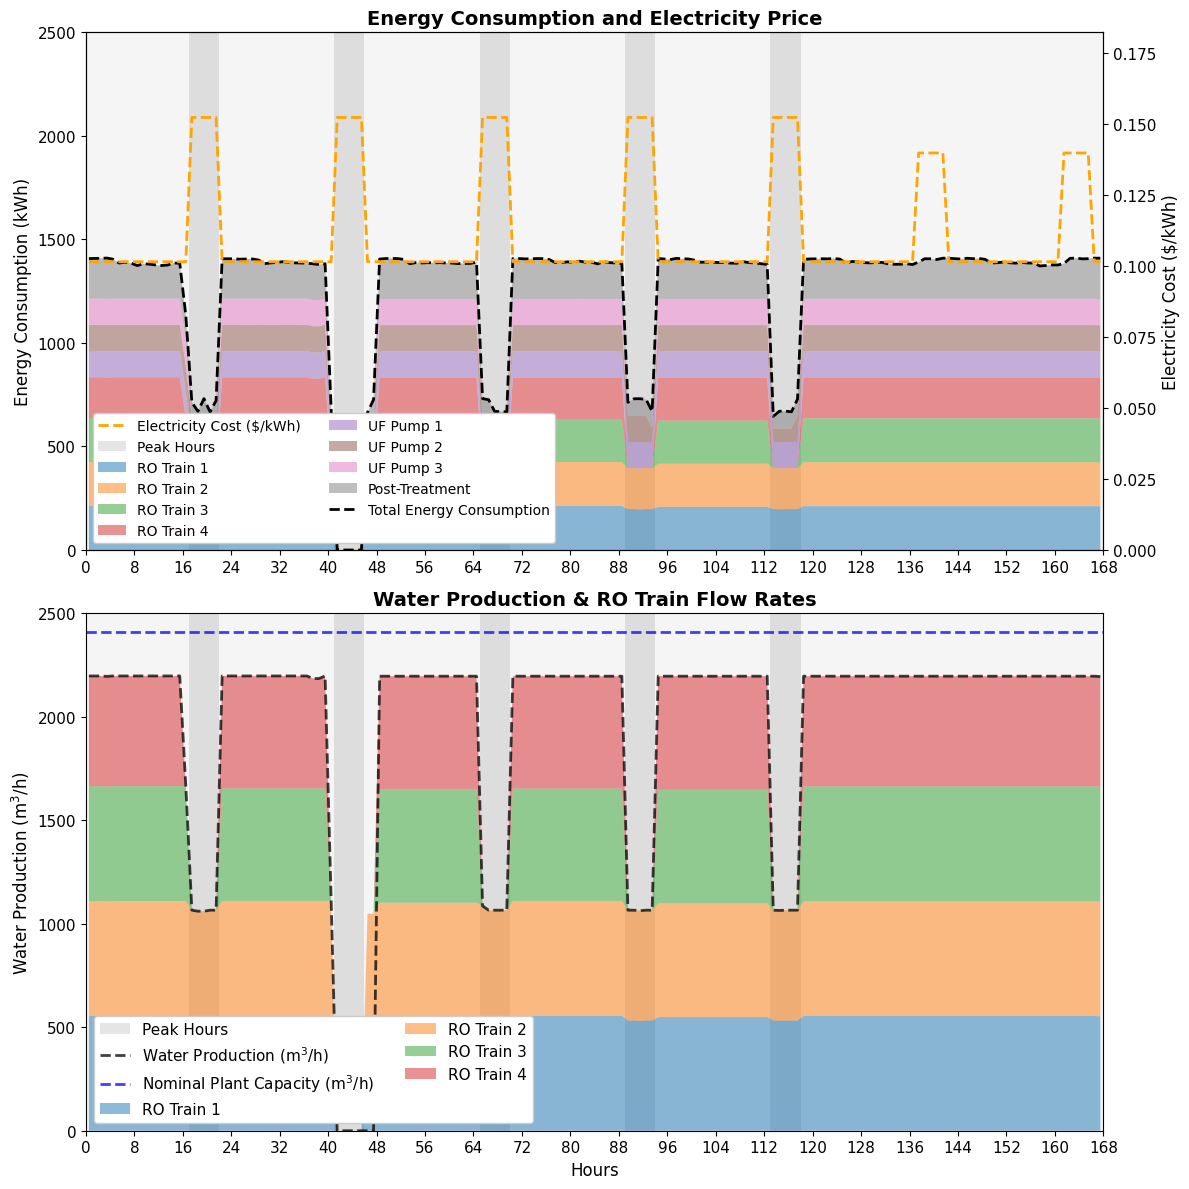

In [13]:
# Maintaining same rate structure to include a demand response event
set_price_data("assets/pricesignal_flex_recovery_and_flow_DR.csv")
run_model(result_name="demand_response_result")

### Real-Time Pricing

2026-09-29 19:01:42 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 

2026-09-29 19:01:42 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 

2026-09-29 19:01:42 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 

2026-09-29 19:01:42 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly



===========================Polynomial Regression===============================================

The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default parameter estimation method is used.
Parameter estimation method:  pyomo 



...


Cutting planes:
  Learned: 70
  Gomory: 20
  Cover: 248
  Implied bound: 764
  Projected implied bound: 40
  Clique: 26
  MIR: 361
  Flow cover: 481
  GUB cover: 123
  RLT: 1186
  Relax-and-lift: 80
  BQP: 143
  PSD: 3



Explored 14791 nodes (11709160 simplex iterations) in 234.80 seconds (421.17 work units)
Thread count was 32 (of 104 available processors)

Solution count 10: 15.5706 15.6758 15.6771 ... 19.1826

Optimal solution found (tolerance 3.00e-02)


Best objective 1.557060564272e+01, best bound 1.539482191628e+01, gap 1.1289%


Maximum power (kW): 1570.66
Discharge energy capacity (kWh): 23227.37
Charge energy capacity (kWh): 64726.70
Levelized Cost of Flexibility ($/kWh): 0.30


Saved operation variable results to: assets/results/real_time_pricing_result.csv


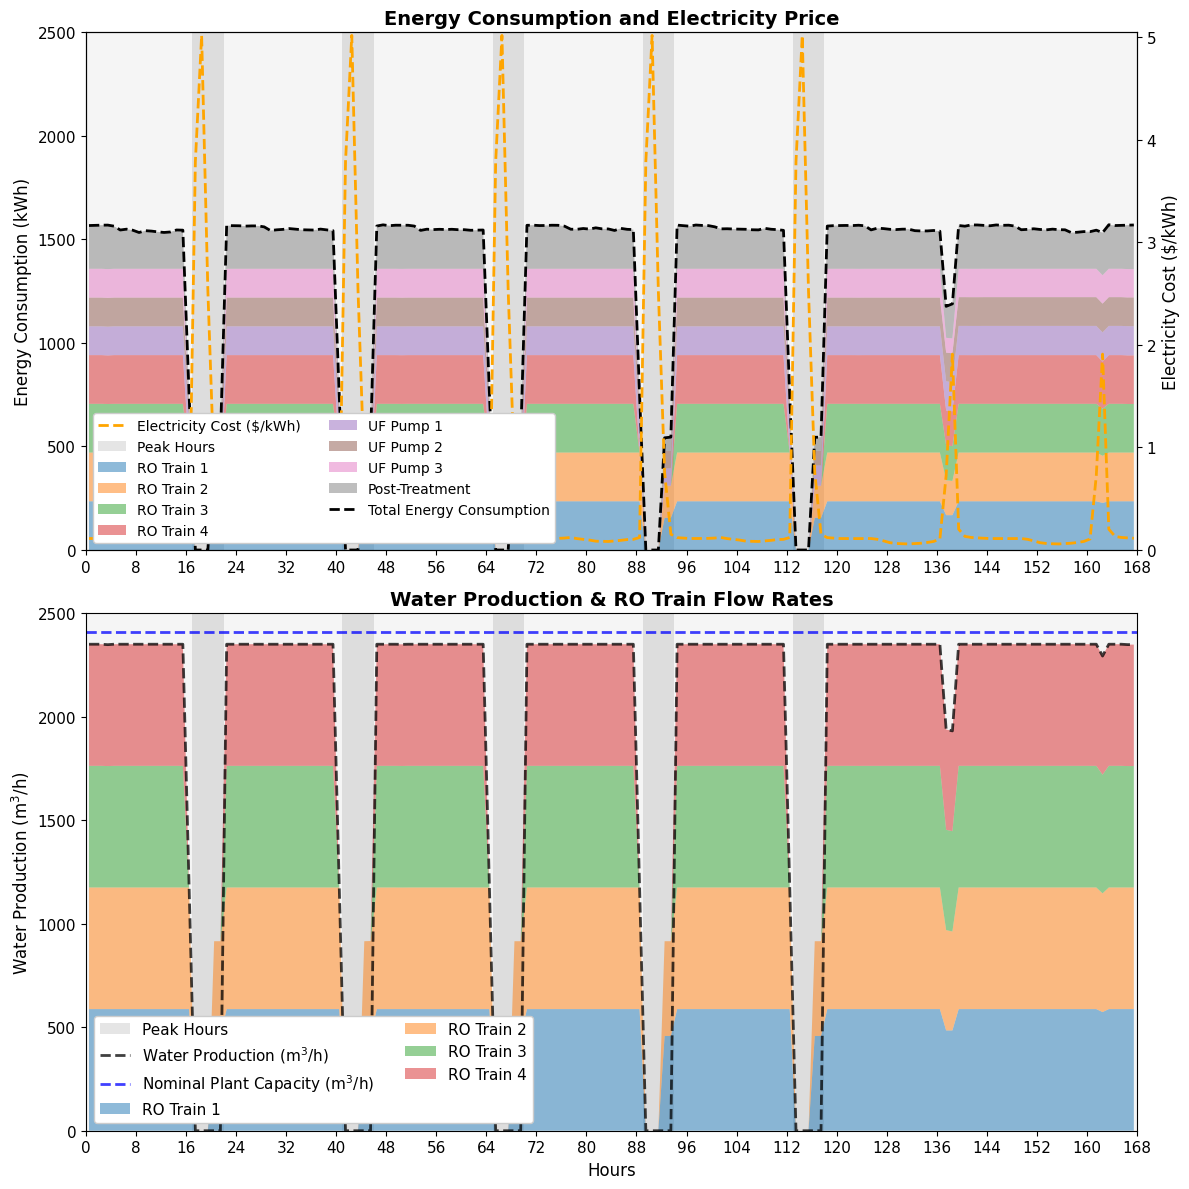

In [14]:
# Changing the rate structure to Real Time Pricing (RTP)
set_price_data("assets/pricesignal_flex_recovery_and_flow_RTP.csv")
run_model(result_name="real_time_pricing_result")